# Comparação Experimental de Algoritmos de Ordenação

## Algoritmos escolhidos
- Bubble Sort → O(n²)
- Merge Sort → O(n log n)
- Quick Sort → O(n²) no pior caso / O(n log n) médio


## Imports

In [1]:
import random
import time
import statistics
import matplotlib.pyplot as plt

## Implementação dos Algoritmos

In [2]:
def bubble_sort(arr):
    arr = arr.copy()
    trocas = 0
    n = len(arr)

    for i in range(n):
        for j in range(0, n - i - 1):
            if arr[j] > arr[j + 1]:
                arr[j], arr[j + 1] = arr[j + 1], arr[j]
                trocas += 1

    return arr, trocas

In [3]:
def merge_sort(arr):
    movimentacoes = [0]

    def merge_sort_rec(lista):
        if len(lista) <= 1:
            return lista

        meio = len(lista) // 2

        esquerda = merge_sort_rec(lista[:meio])
        direita = merge_sort_rec(lista[meio:])

        return merge(esquerda, direita)

    def merge(esquerda, direita):
        resultado = []
        i = j = 0

        while i < len(esquerda) and j < len(direita):
            if esquerda[i] < direita[j]:
                resultado.append(esquerda[i])
                i += 1
            else:
                resultado.append(direita[j])
                j += 1

            movimentacoes[0] += 1

        resultado.extend(esquerda[i:])
        resultado.extend(direita[j:])

        movimentacoes[0] += len(esquerda[i:])
        movimentacoes[0] += len(direita[j:])

        return resultado

    resultado = merge_sort_rec(arr.copy())

    return resultado, movimentacoes[0]

In [4]:
def quick_sort(arr):
    arr = arr.copy()
    trocas = [0]

    def quicksort(lista, inicio, fim):
        if inicio < fim:
            p = particionar(lista, inicio, fim)
            quicksort(lista, inicio, p - 1)
            quicksort(lista, p + 1, fim)

    def particionar(lista, inicio, fim):
        pivot = lista[fim]
        i = inicio - 1

        for j in range(inicio, fim):
            if lista[j] <= pivot:
                i += 1
                lista[i], lista[j] = lista[j], lista[i]
                trocas[0] += 1

        lista[i + 1], lista[fim] = lista[fim], lista[i + 1]
        trocas[0] += 1

        return i + 1

    quicksort(arr, 0, len(arr) - 1)

    return arr, trocas[0]

## Geração dos Vetores

In [5]:
tamanhos = [1000, 10000, 100000]

vetores = {}

for tamanho in tamanhos:
    vetores[tamanho] = [
        random.randint(0, 1000000)
        for _ in range(tamanho)
    ]

## Execução dos Testes

In [6]:
algoritmos = {
    "Bubble Sort": bubble_sort,
    "Merge Sort": merge_sort,
    "Quick Sort": quick_sort
}

resultados = []

LIMITE = 300  # 5 minutos

for tamanho in tamanhos:

    vetor_original = vetores[tamanho]

    for nome, algoritmo in algoritmos.items():

        tempos = []
        operacoes = []

        print(f"Executando {nome} com {tamanho} elementos")

        interrompido = False

        for execucao in range(3):

            vetor = vetor_original.copy()

            inicio = time.time()

            _, ops = algoritmo(vetor)

            fim = time.time()

            tempo = fim - inicio

            if tempo > LIMITE:
                interrompido = True
                break

            tempos.append(tempo)
            operacoes.append(ops)

        if interrompido:
            resultados.append({
                "Algoritmo": nome,
                "Tamanho": tamanho,
                "Execução 1": "Interrompido",
                "Execução 2": "Interrompido",
                "Execução 3": "Interrompido",
                "Tempo Médio": "Interrompido",
                "Desvio Padrão": "Interrompido",
                "Operações": "Interrompido"
            })

        else:
            resultados.append({
                "Algoritmo": nome,
                "Tamanho": tamanho,
                "Execução 1": tempos[0],
                "Execução 2": tempos[1],
                "Execução 3": tempos[2],
                "Tempo Médio": statistics.mean(tempos),
                "Desvio Padrão": statistics.stdev(tempos),
                "Operações": int(statistics.mean(operacoes))
            })

Executando Bubble Sort com 1000 elementos
Executando Merge Sort com 1000 elementos
Executando Quick Sort com 1000 elementos
Executando Bubble Sort com 10000 elementos
Executando Merge Sort com 10000 elementos
Executando Quick Sort com 10000 elementos
Executando Bubble Sort com 100000 elementos
Executando Merge Sort com 100000 elementos
Executando Quick Sort com 100000 elementos


## Exibição dos Resultados

In [7]:
for resultado in resultados:
    print(resultado)

{'Algoritmo': 'Bubble Sort', 'Tamanho': 1000, 'Execução 1': 0.05260515213012695, 'Execução 2': 0.044458627700805664, 'Execução 3': 0.04357624053955078, 'Tempo Médio': 0.04688000679016113, 'Desvio Padrão': 0.004977712190192008, 'Operações': 245608}
{'Algoritmo': 'Merge Sort', 'Tamanho': 1000, 'Execução 1': 0.002190113067626953, 'Execução 2': 0.002100706100463867, 'Execução 3': 0.0020885467529296875, 'Tempo Médio': 0.002126455307006836, 'Desvio Padrão': 5.546345912842389e-05, 'Operações': 9976}
{'Algoritmo': 'Quick Sort', 'Tamanho': 1000, 'Execução 1': 0.0011663436889648438, 'Execução 2': 0.0011219978332519531, 'Execução 3': 0.0011279582977294922, 'Tempo Médio': 0.001138766606648763, 'Desvio Padrão': 2.4067683436465602e-05, 'Operações': 5920}
{'Algoritmo': 'Bubble Sort', 'Tamanho': 10000, 'Execução 1': 5.31413722038269, 'Execução 2': 4.86607813835144, 'Execução 3': 4.863063097000122, 'Tempo Médio': 5.014426151911418, 'Desvio Padrão': 0.2595617769274427, 'Operações': 25129706}
{'Algoritmo

## Geração do Gráfico

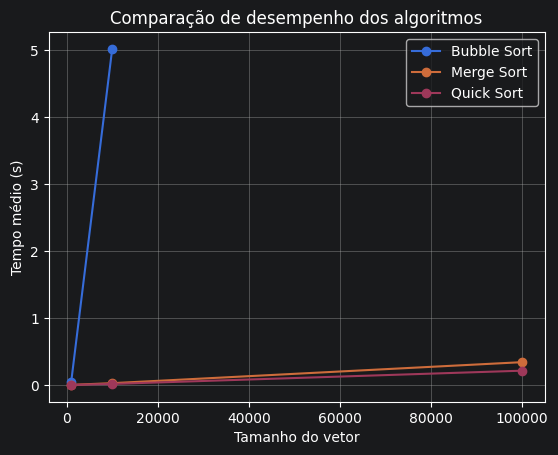

In [8]:
dados_grafico = {}

for resultado in resultados:

    if resultado["Tempo Médio"] == "Interrompido":
        continue

    algoritmo = resultado["Algoritmo"]

    if algoritmo not in dados_grafico:
        dados_grafico[algoritmo] = {
            "x": [],
            "y": []
        }

    dados_grafico[algoritmo]["x"].append(resultado["Tamanho"])
    dados_grafico[algoritmo]["y"].append(resultado["Tempo Médio"])


for algoritmo, dados in dados_grafico.items():
    plt.plot(
        dados["x"],
        dados["y"],
        marker="o",
        label=algoritmo
    )

plt.xlabel("Tamanho do vetor")
plt.ylabel("Tempo médio (s)")
plt.title("Comparação de desempenho dos algoritmos")
plt.legend()
plt.grid(True)

plt.show()

# Análise dos Resultados

## Bubble Sort
O Bubble Sort apresentou crescimento quadrático, tornando-se muito lento para vetores grandes. Isso está coerente com sua complexidade teórica O(n²).

## Merge Sort
O Merge Sort apresentou desempenho significativamente melhor, mantendo crescimento próximo de O(n log n). O número de movimentações foi elevado devido às intercalações.

## Quick Sort
O Quick Sort apresentou desempenho muito eficiente na maioria dos testes, também compatível com O(n log n) no caso médio.

## Conclusão
Os resultados experimentais ficaram coerentes com a análise teórica estudada em sala. Algoritmos quadráticos cresceram rapidamente em tempo de execução, enquanto algoritmos O(n log n) escalaram muito melhor para entradas grandes.
